# Наивный байесовский классификатор

**Цель работы:** научиться применять модели наивного байесовского классификатора с использованием sklearn.

**Содержание работы:**
1. Загрузка датасета *breast_cancer*, анализ распределения признаков.
2. Построение GaussianNB на первых двух столбцах.
3. Построение модели на полном датасете.
4. Отбор признаков с нормальным распределением — сравнение качества.

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

## 2. Загрузка данных (2 признака)

In [2]:
data = datasets.load_breast_cancer()
X_2d = data.data[:, :2]
y = data.target

df_2d = pd.DataFrame(X_2d, columns=data.feature_names[:2])
df_2d['target'] = y
print('Распределение целевой переменной:')
print(df_2d['target'].value_counts())
print(f'\nРазмер X: {X_2d.shape}, y: {y.shape}')

Распределение целевой переменной:
target
1    357
0    212
Name: count, dtype: int64

Размер X: (569, 2), y: (569,)


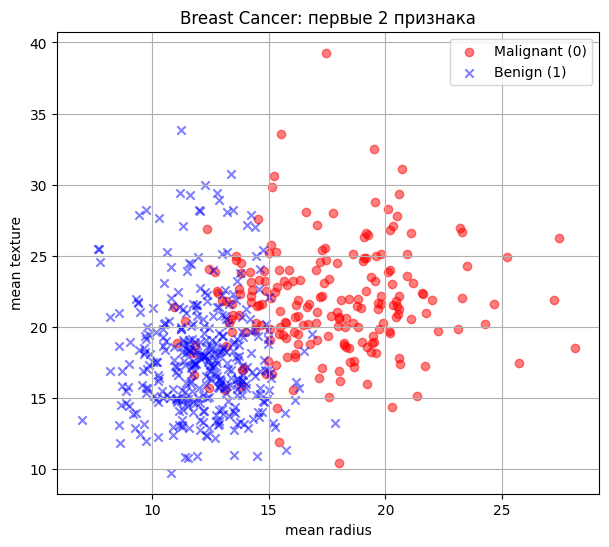

In [3]:
plt.figure(figsize=(7, 6))
plt.scatter(X_2d[:, 0][y == 0], X_2d[:, 1][y == 0], marker='o', c='r', alpha=0.5, label='Malignant (0)')
plt.scatter(X_2d[:, 0][y == 1], X_2d[:, 1][y == 1], marker='x', c='b', alpha=0.5, label='Benign (1)')
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title('Breast Cancer: первые 2 признака')
plt.legend()
plt.grid(True)
plt.show()

Классы сильно перемешаны — данные линейно неразделимы.

### Гистограммы признаков

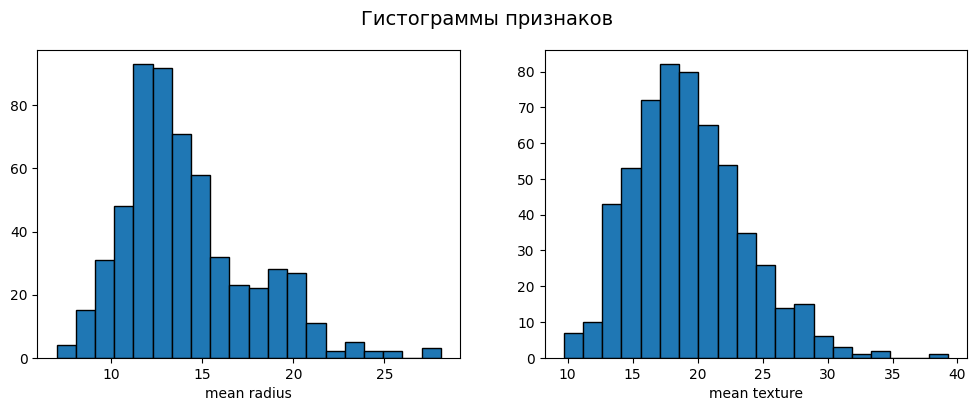

In [4]:
plt.figure(figsize=(12, 4))
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.hist(X_2d[:, i], bins=20, edgecolor='k')
    plt.xlabel(data.feature_names[i])
plt.suptitle('Гистограммы признаков', fontsize=14)
plt.show()

Распределение признаков напоминает нормальное — можно применить GaussianNB.

### GaussianNB (2 признака)

In [5]:
gaussian_nb = GaussianNB()
gaussian_nb.fit(X_2d, y)

y_pred_2d = gaussian_nb.predict(X_2d)

print('Матрица классификации (2 признака):')
print(confusion_matrix(y, y_pred_2d))
print(f'Accuracy = {accuracy_score(y, y_pred_2d):.4f}')
print(f'F1_score = {f1_score(y, y_pred_2d):.4f}')

Матрица классификации (2 признака):
[[164  48]
 [ 17 340]]
Accuracy = 0.8858
F1_score = 0.9128


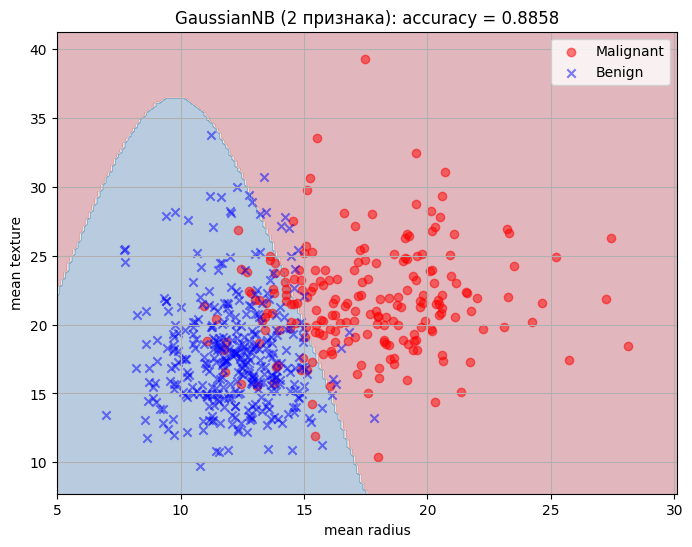

In [6]:
xx_nb, yy_nb = np.meshgrid(
    np.linspace(X_2d[:, 0].min() - 2, X_2d[:, 0].max() + 2, 200),
    np.linspace(X_2d[:, 1].min() - 2, X_2d[:, 1].max() + 2, 200)
)
XX_nb = np.c_[xx_nb.ravel(), yy_nb.ravel()]
Z_nb = gaussian_nb.predict(XX_nb).reshape(xx_nb.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx_nb, yy_nb, Z_nb, alpha=0.3, cmap='RdBu')
plt.scatter(X_2d[:, 0][y == 0], X_2d[:, 1][y == 0], marker='o', c='r', alpha=0.5, label='Malignant')
plt.scatter(X_2d[:, 0][y == 1], X_2d[:, 1][y == 1], marker='x', c='b', alpha=0.5, label='Benign')
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title(f'GaussianNB (2 признака): accuracy = {accuracy_score(y, y_pred_2d):.4f}')
plt.legend()
plt.grid(True)
plt.show()

## 3. Модель на полном датасете (30 признаков)

In [7]:
X_full = data.data
print(f'Размер полного X: {X_full.shape}')

gaussian_nb.fit(X_full, y)
y_pred_full = gaussian_nb.predict(X_full)

print('\nМатрица классификации (30 признаков):')
print(confusion_matrix(y, y_pred_full))
print(f'Accuracy = {accuracy_score(y, y_pred_full):.4f}')
print(f'F1_score = {f1_score(y, y_pred_full):.4f}')

Размер полного X: (569, 30)

Матрица классификации (30 признаков):
[[189  23]
 [ 10 347]]
Accuracy = 0.9420
F1_score = 0.9546


Accuracy выросла до ~94% — больше информации о пациентах даёт более точные предсказания.

## 4. Анализ распределений всех признаков

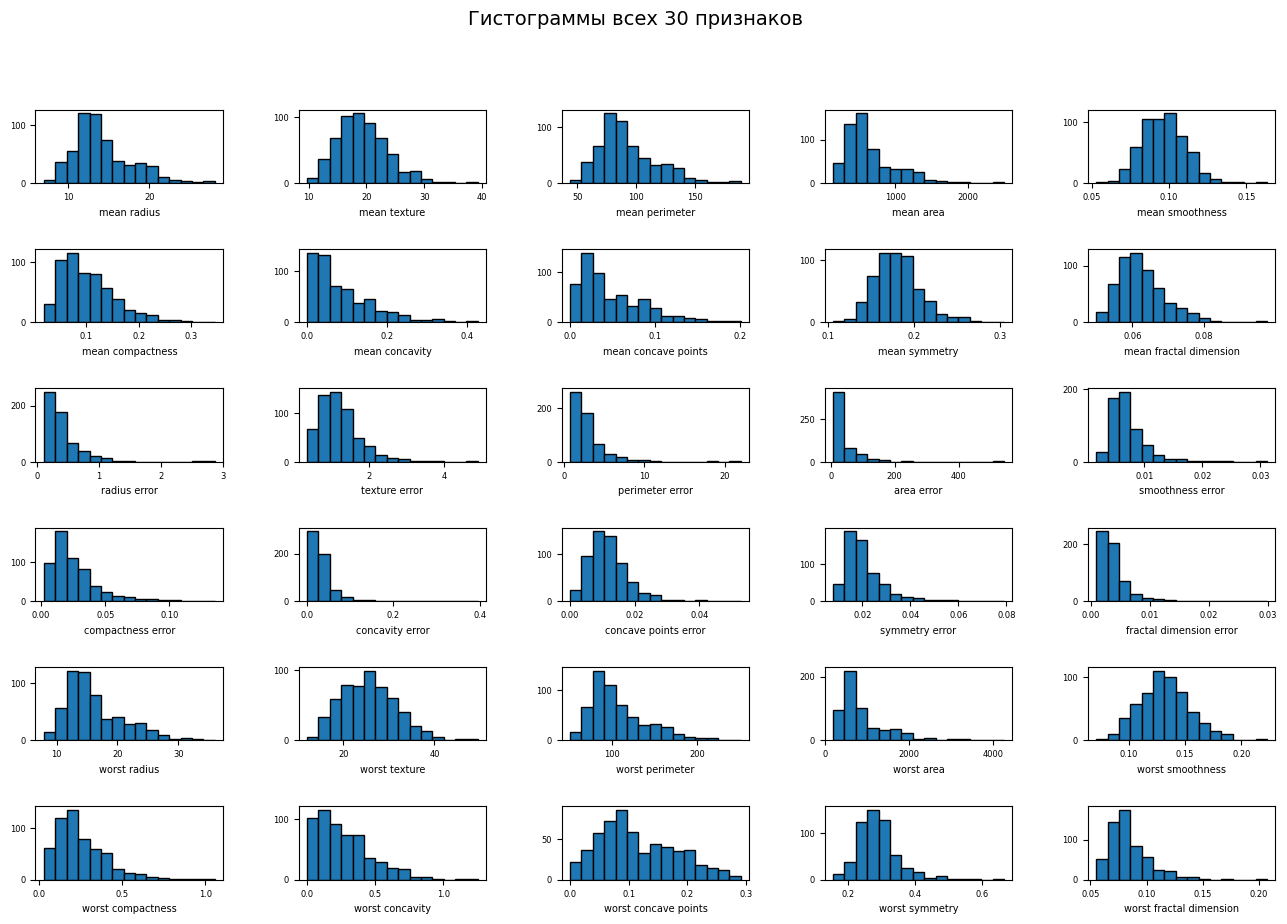

In [8]:
f = plt.figure(figsize=(16, 10))
for i in range(30):
    plt.subplot(6, 5, i + 1)
    plt.hist(X_full[:, i], bins=15, edgecolor='k')
    plt.xlabel(data.feature_names[i], fontsize=7)
    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)
f.subplots_adjust(hspace=0.9, wspace=0.4)
plt.suptitle('Гистограммы всех 30 признаков', fontsize=14)
plt.show()

У большинства признаков распределение близко к нормальному, но некоторые (например, concavity errors, area errors) сильно отличаются.

## 5. Модель на отобранных признаках

In [9]:
drop_features = ['mean concavity', 'radius error', 'perimeter error', 'area error',
                 'compactness error', 'concavity error', 'fractal dimension error',
                 'worst area', 'worst concavity']

keep_idx = [i for i, name in enumerate(data.feature_names) if name not in drop_features]
X_selected = X_full[:, keep_idx]

print(f'Убрано признаков: {len(drop_features)}')
print(f'Осталось признаков: {X_selected.shape[1]}')
print(f'\nУбраны: {drop_features}')

Убрано признаков: 9
Осталось признаков: 21

Убраны: ['mean concavity', 'radius error', 'perimeter error', 'area error', 'compactness error', 'concavity error', 'fractal dimension error', 'worst area', 'worst concavity']


In [10]:
gaussian_nb.fit(X_selected, y)
y_pred_sel = gaussian_nb.predict(X_selected)

print('Матрица классификации (отобранные признаки):')
print(confusion_matrix(y, y_pred_sel))
print(f'Accuracy = {accuracy_score(y, y_pred_sel):.4f}')
print(f'F1_score = {f1_score(y, y_pred_sel):.4f}')

Матрица классификации (отобранные признаки):
[[196  16]
 [ 15 342]]
Accuracy = 0.9455
F1_score = 0.9566


In [11]:
comparison = pd.DataFrame({
    'Модель': ['2 признака', '30 признаков (все)', f'{X_selected.shape[1]} признаков (отобранные)'],
    'Accuracy': [accuracy_score(y, y_pred_2d), accuracy_score(y, y_pred_full), accuracy_score(y, y_pred_sel)],
    'F1-score': [f1_score(y, y_pred_2d), f1_score(y, y_pred_full), f1_score(y, y_pred_sel)]
})
display(comparison.round(4))

,Модель,Accuracy,F1-score
0,2 признака,0.8858,0.9128
1,30 признаков (все),0.9420,0.9546
2,21 признаков (отобранные),0.9455,0.9566


## Выводы

1. **2 признака**: GaussianNB даёт accuracy ~88.6%. Модель работает даже на ограниченном наборе данных.
2. **30 признаков**: accuracy ~94.2% — использование всех признаков существенно повышает точность.
3. **Отбор признаков**: удаление признаков с ненормальным распределением может слегка повысить точность (~94.6%), поскольку такие признаки «запутывают» классификатор, а не добавляют полезной информации.
4. GaussianNB предполагает нормальность распределения признаков — важно проверять гистограммы перед применением.